In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Banking Risk Analytics Project

## Problem Statement
Develop a basic understanding of risk analytics in banking and financial services and understand how data is used to minimise the risk of losing money while lending to customers.

## Project Objectives
- Perform comprehensive data analysis on banking loan data
- Identify key risk factors for loan default
- Clean and transform data for analysis
- Create visualizations to understand patterns
- Build insights for risk assessment

## Dataset Overview
This project analyzes a banking dataset containing customer information and loan details to assess credit risk.

In [3]:
!pip install openpyxl

## 1. Data Loading and Initial Exploration

In [4]:
df = pd.read_excel('Banking.xlsx')
df.head()

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,2019-05-06,Anthony Torres,American,Safety Technician IV,High,Jade,...,1.485829e+06,6.036179e+05,607332.455240,12249.9584,1.134475e+06,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,2001-12-10,Jonathan Hawkins,African,Software Consultant,High,Jade,...,6.414828e+05,2.295214e+05,344635.157402,61162.3089,2.000526e+06,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,2010-01-25,Anthony Berry,European,Help Desk Operator,High,Gold,...,1.033402e+06,6.526747e+05,203054.348179,79071.7794,5.481376e+05,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,2019-03-28,Steve Diaz,American,Geologist II,Mid,Silver,...,1.048157e+06,1.048157e+06,234685.019326,57513.6520,1.148402e+06,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,2012-07-20,Shawn Long,American,Assistant Professor,Mid,Platinum,...,4.877825e+05,4.466442e+05,128351.452320,30012.1360,1.674412e+06,0,3,1,2,5


In [5]:
# Get basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names:", list(df.columns))
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (3000, 25)

Column Names: ['Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank', 'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure', 'Loyalty Classification', 'Estimated Income', 'Superannuation Savings', 'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans', 'Bank Deposits', 'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account', 'Business Lending', 'Properties Owned', 'Risk Weighting', 'BRId', 'GenderId', 'IAId']

Data Types:
Client ID                              str
Name                                   str
Age                                  int64
Location ID                          int64
Joined Bank                 datetime64[us]
Banking Contact                        str
Nationality                            str
Occupation                             str
Fee Structure                          str
Loyalty Classification                 str
Estimated Income                   float64
Superannuation Savings             float64


In [6]:
df.isnull().sum()

Client ID                   0
Name                        0
Age                         0
Location ID                 0
Joined Bank                 0
Banking Contact             0
Nationality                 0
Occupation                  0
Fee Structure               0
Loyalty Classification      0
Estimated Income            0
Superannuation Savings      0
Amount of Credit Cards      0
Credit Card Balance         0
Bank Loans                  0
Bank Deposits               0
Checking Accounts           0
Saving Accounts             0
Foreign Currency Account    0
Business Lending            0
Properties Owned            0
Risk Weighting              0
BRId                        0
GenderId                    0
IAId                        0
dtype: int64

## 2. Data Cleaning and Preprocessing

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Client ID                 3000 non-null   str           
 1   Name                      3000 non-null   str           
 2   Age                       3000 non-null   int64         
 3   Location ID               3000 non-null   int64         
 4   Joined Bank               3000 non-null   datetime64[us]
 5   Banking Contact           3000 non-null   str           
 6   Nationality               3000 non-null   str           
 7   Occupation                3000 non-null   str           
 8   Fee Structure             3000 non-null   str           
 9   Loyalty Classification    3000 non-null   str           
 10  Estimated Income          3000 non-null   float64       
 11  Superannuation Savings    3000 non-null   float64       
 12  Amount of Credit Cards    3000 

In [8]:
# Check for duplicates
print("Number of duplicate rows:", df.duplicated().sum())

# Handle missing values (if any)
# For numerical columns, fill with median
# For categorical columns, fill with mode

# First, let's see which columns have missing values
missing_cols = df.columns[df.isnull().any()]
if len(missing_cols) > 0:
    print("\nColumns with missing values:", list(missing_cols))

    # Handle numerical columns
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in num_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
            print(f"Filled missing values in {col} with median")

    # Handle categorical columns
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f"Filled missing values in {col} with mode")
else:
    print("No missing values found!")

# Convert data types if necessary
# Check for date columns that might be strings
date_cols = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]
if date_cols:
    for col in date_cols:
        try:
            df[col] = pd.to_datetime(df[col])
            print(f"Converted {col} to datetime")
        except:
            print(f"Could not convert {col} to datetime")

print("\nData cleaning completed!")

Number of duplicate rows: 0
No missing values found!

Data cleaning completed!


## 3. Exploratory Data Analysis (EDA)

In [9]:
bins = [0, 100000, 300000, float('inf')]
labels = ['Low', 'Med', 'High']

df['Income Band'] = pd.cut(df['Estimated Income'], bins=bins, labels=labels, right=False)

<Axes: xlabel='Income Band'>

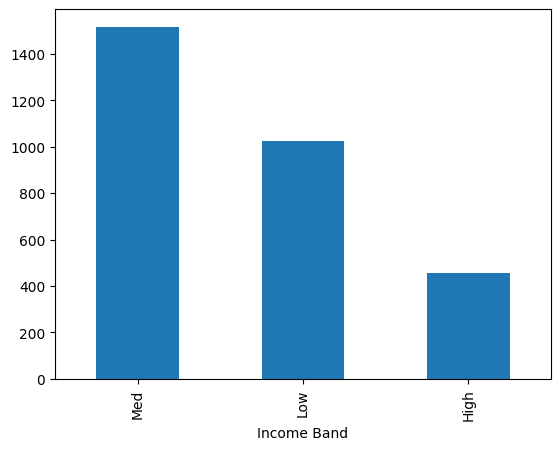

In [10]:
df['Income Band'].value_counts().plot(kind='bar')

In [11]:
# Examine the distribution of unique cataegories in categorical columns
categorical_cols = df[["BRId", "GenderId", "IAId", "Amount of Credit Cards", "Nationality", "Occupation", "Fee Structure", "Loyalty Classification", "Properties Owned", "Risk Weighting", "Income Band"]].columns

for col in categorical_cols:
  print(f"Value Counts for '{col}':")
  display(df[col].value_counts())

Value Counts for 'BRId':


BRId
3    1352
1     660
2     495
4     493
Name: count, dtype: int64

Value Counts for 'GenderId':


GenderId
2    1512
1    1488
Name: count, dtype: int64

Value Counts for 'IAId':


...

Properties Owned
2    777
1    776
3    742
0    705
Name: count, dtype: int64

Value Counts for 'Risk Weighting':


Risk Weighting
2    1222
1     836
3     460
4     322
5     160
Name: count, dtype: int64

Value Counts for 'Income Band':


Income Band
Med     1517
Low     1027
High     456
Name: count, dtype: int64

# Univariate Analysis

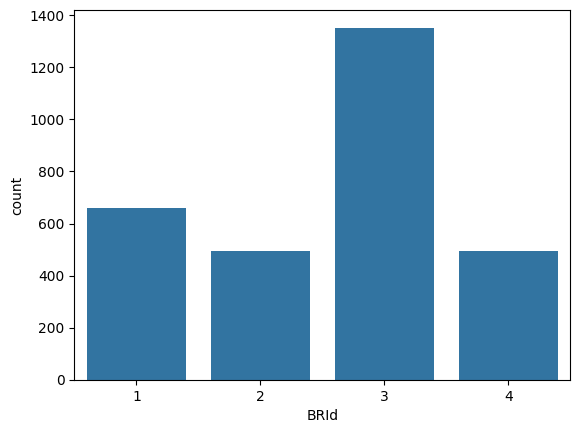

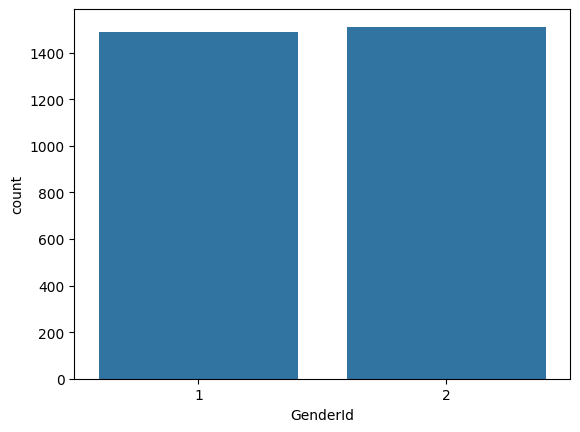

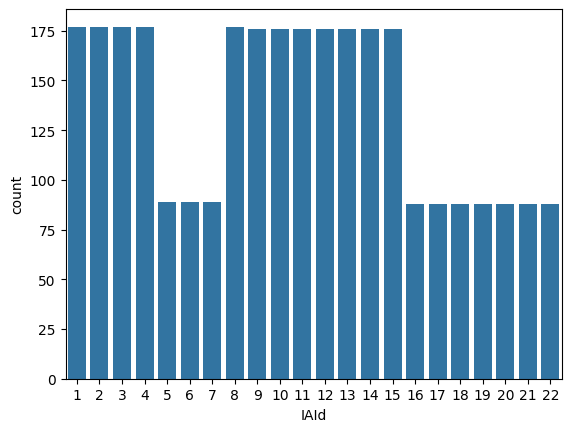

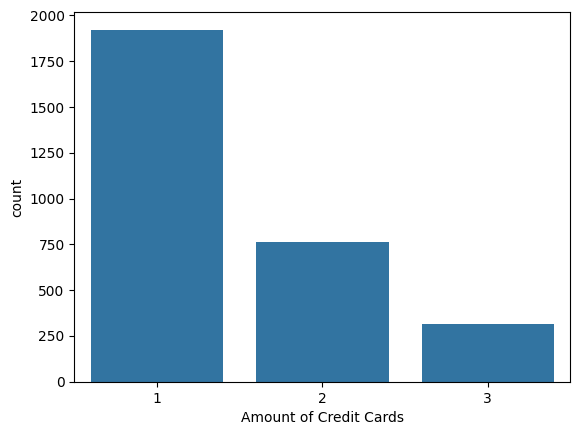

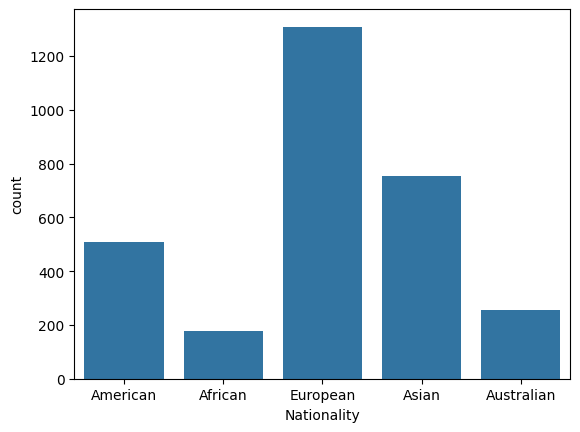

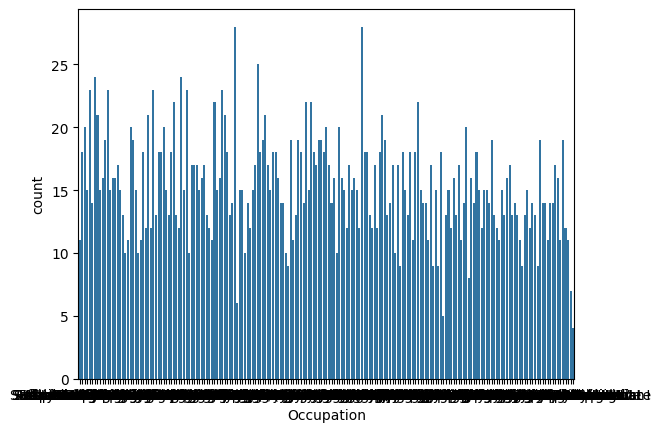

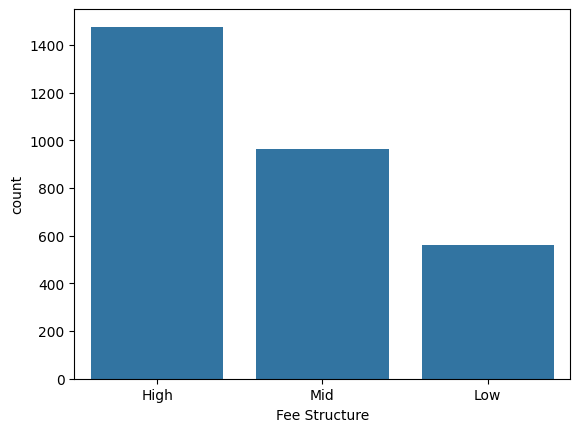

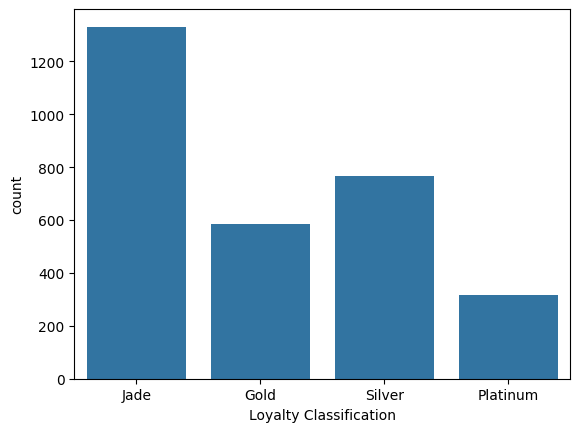

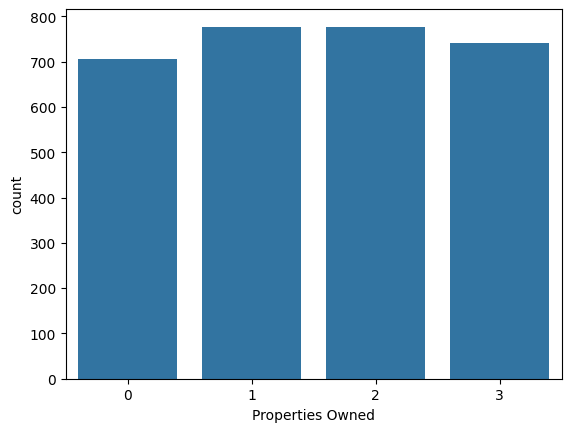

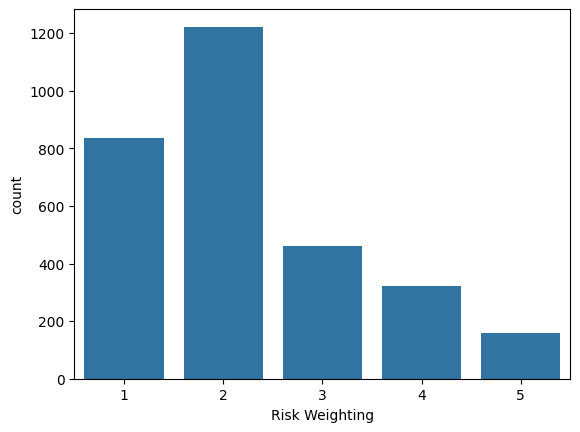

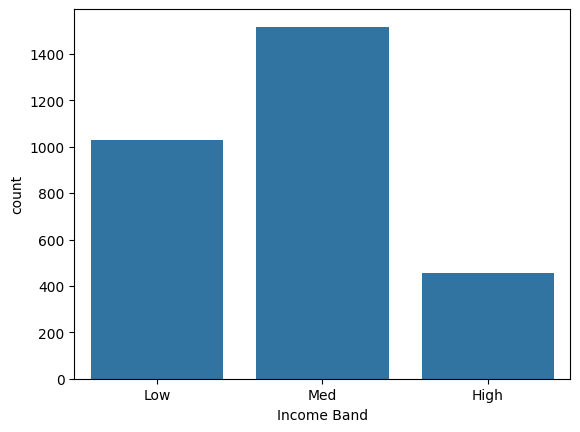

In [12]:
for i, predictor in enumerate(df[["BRId", "GenderId", "IAId", "Amount of Credit Cards", "Nationality", "Occupation", "Fee Structure", "Loyalty Classification", "Properties Owned", "Risk Weighting", "Income Band"]].columns):
    plt.figure(i)
    sns.countplot(data=df, x=predictor)

# Bivariate Analysis

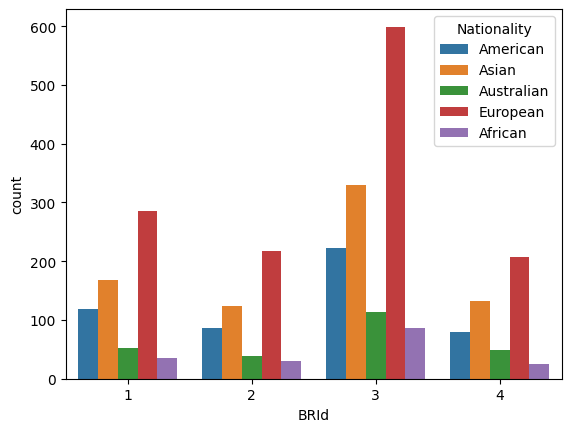

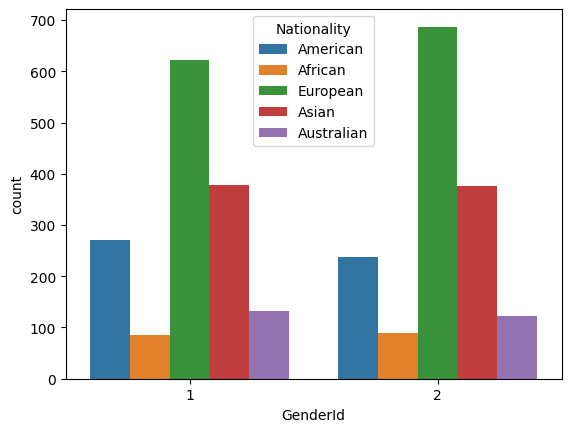

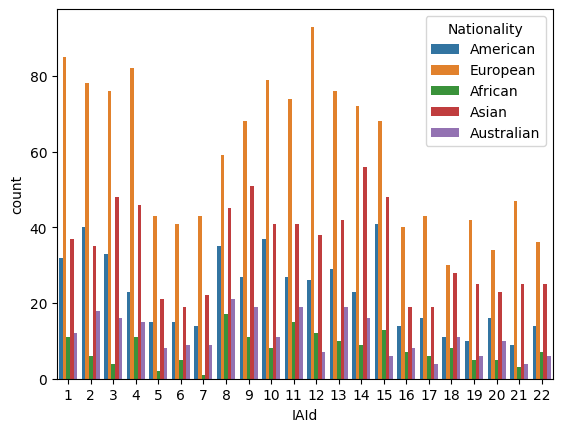

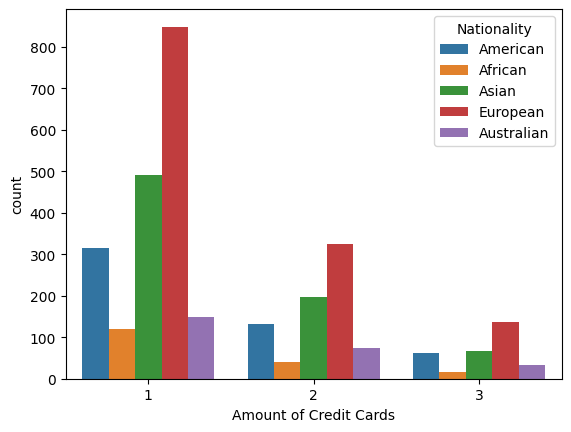

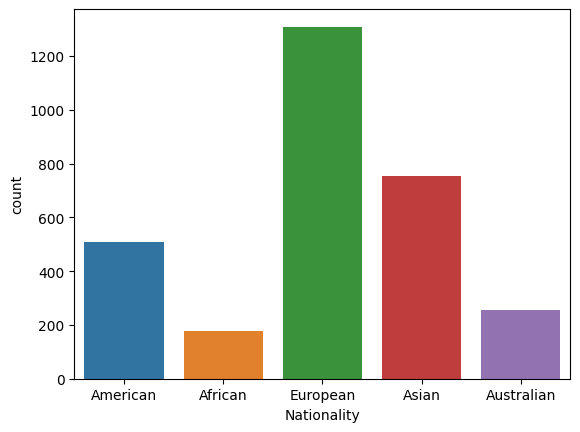

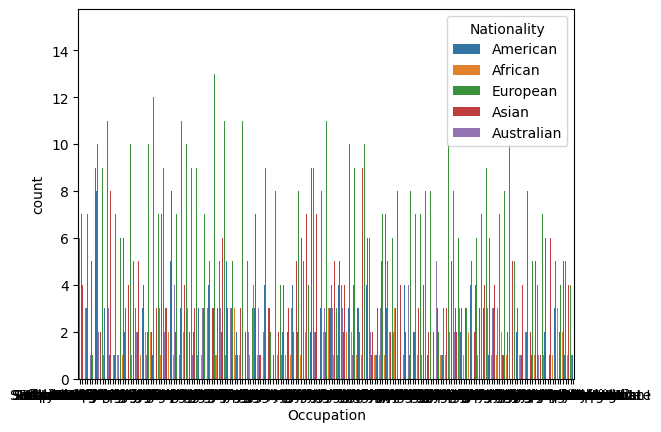

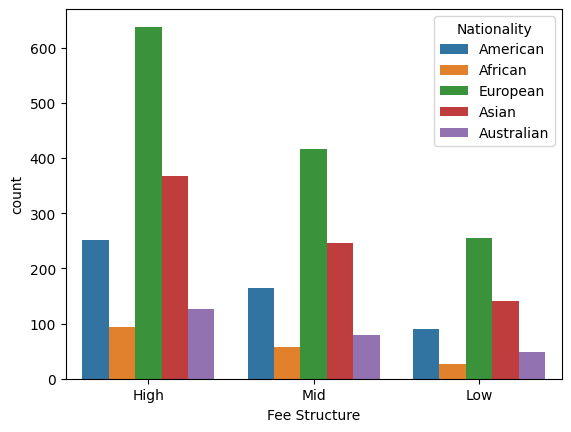

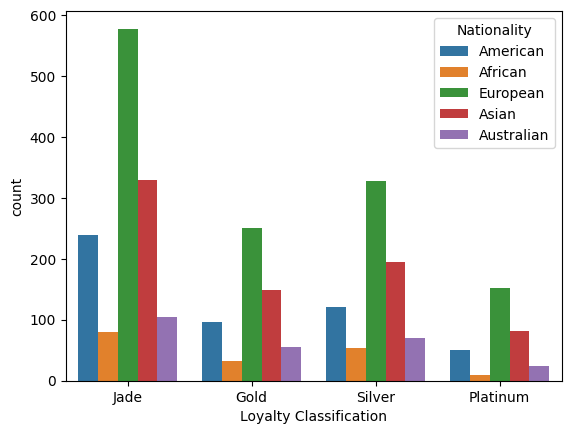

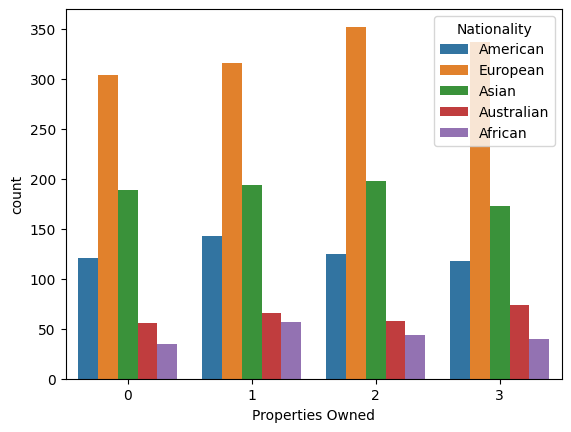

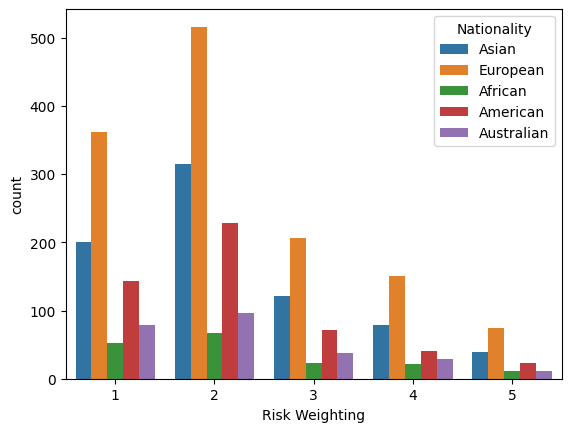

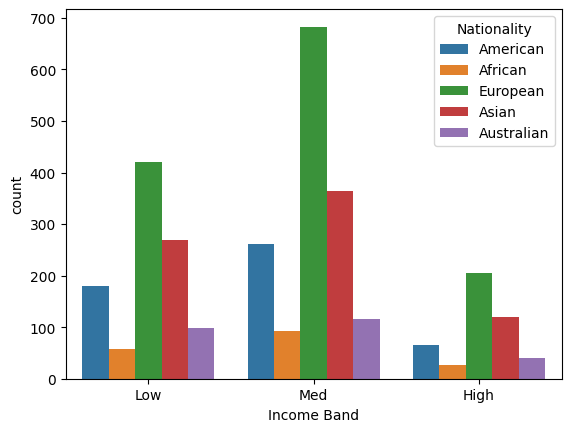

In [13]:
for i, predictor in enumerate(df[["BRId", "GenderId", "IAId", "Amount of Credit Cards", "Nationality", "Occupation", "Fee Structure", "Loyalty Classification", "Properties Owned", "Risk Weighting", "Income Band"]].columns):
    plt.figure(i)
    sns.countplot(data=df, x=predictor, hue='Nationality')

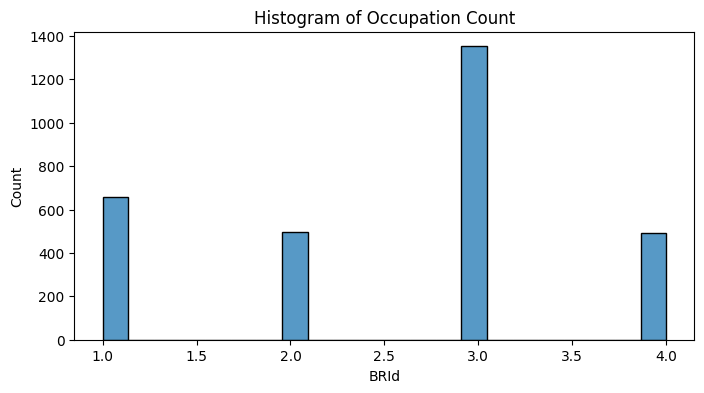

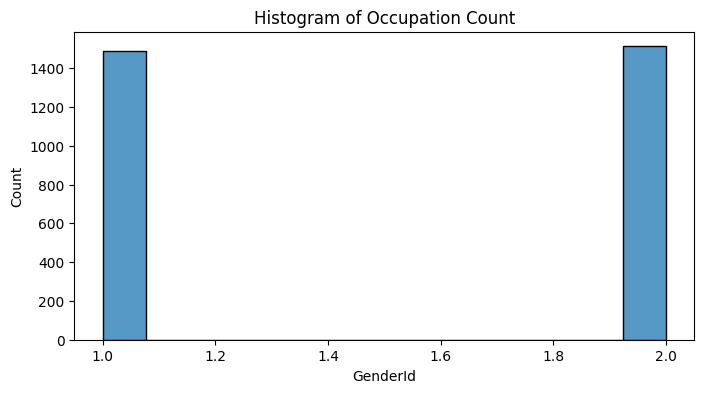

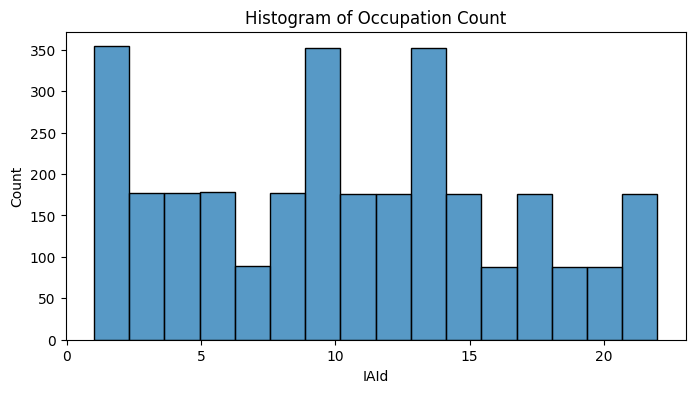

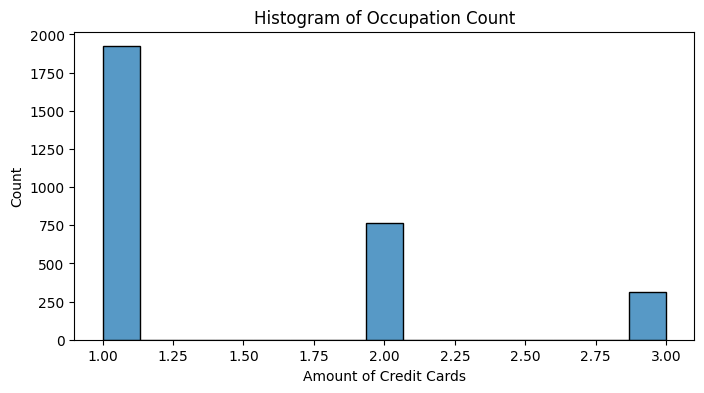

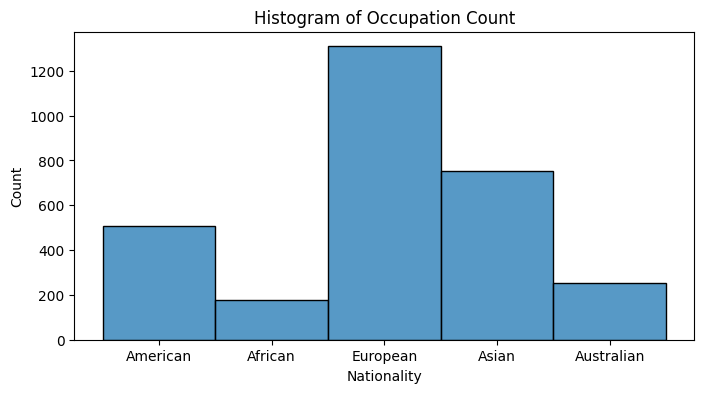

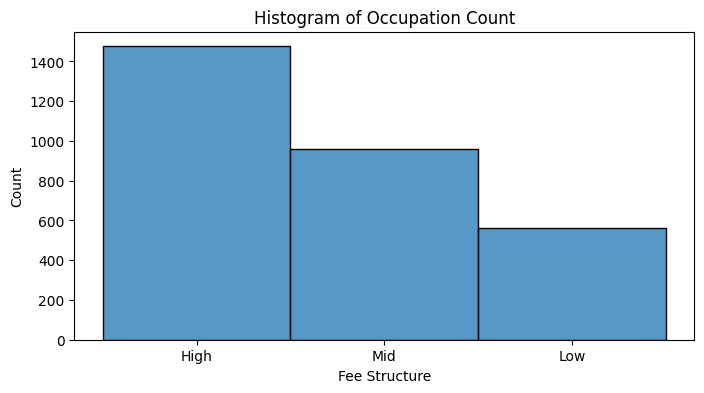

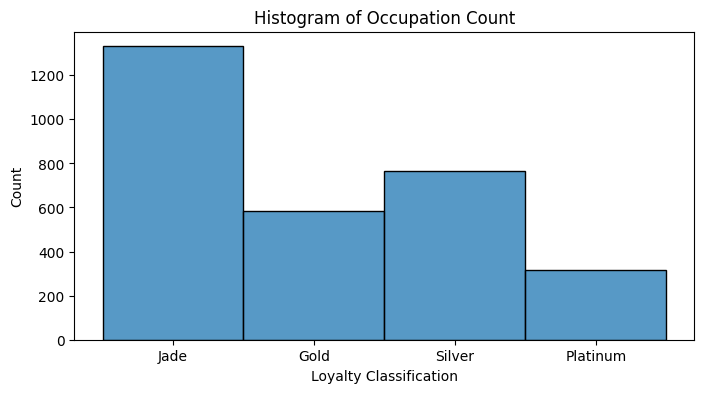

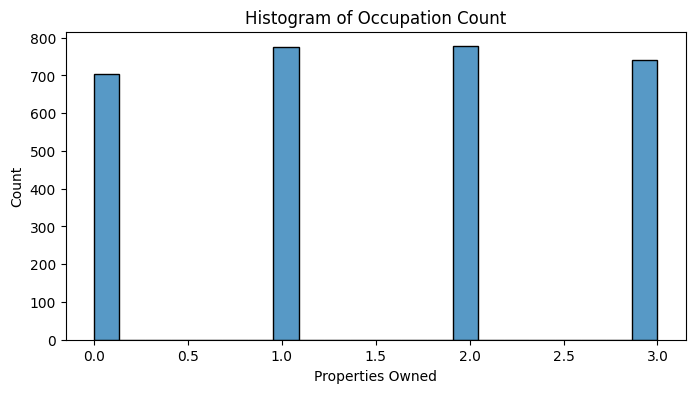

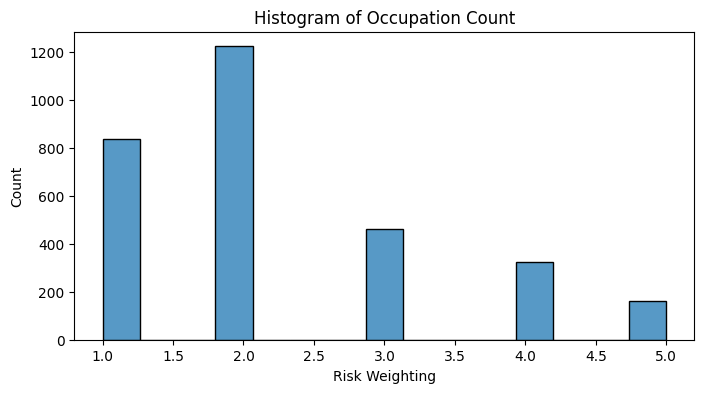

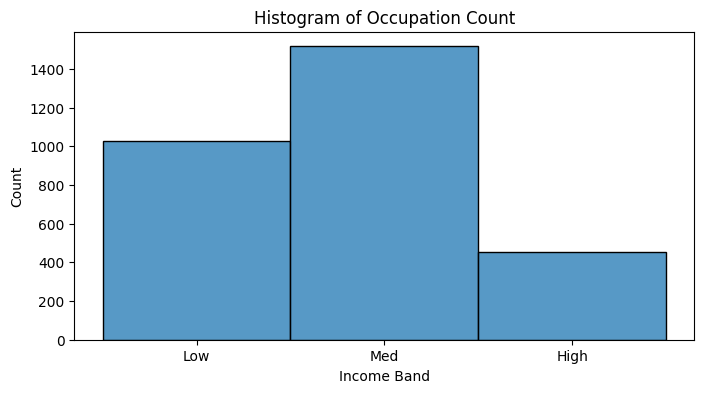

In [14]:
# HIstplot of value counts for different Occupation

for col in categorical_cols:
  if col == "Occupation":
    continue
  plt.figure(figsize=(8,4))
  sns.histplot(df[col])
  plt.title('Histogram of Occupation Count')
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.show()

# Numerical Analysis

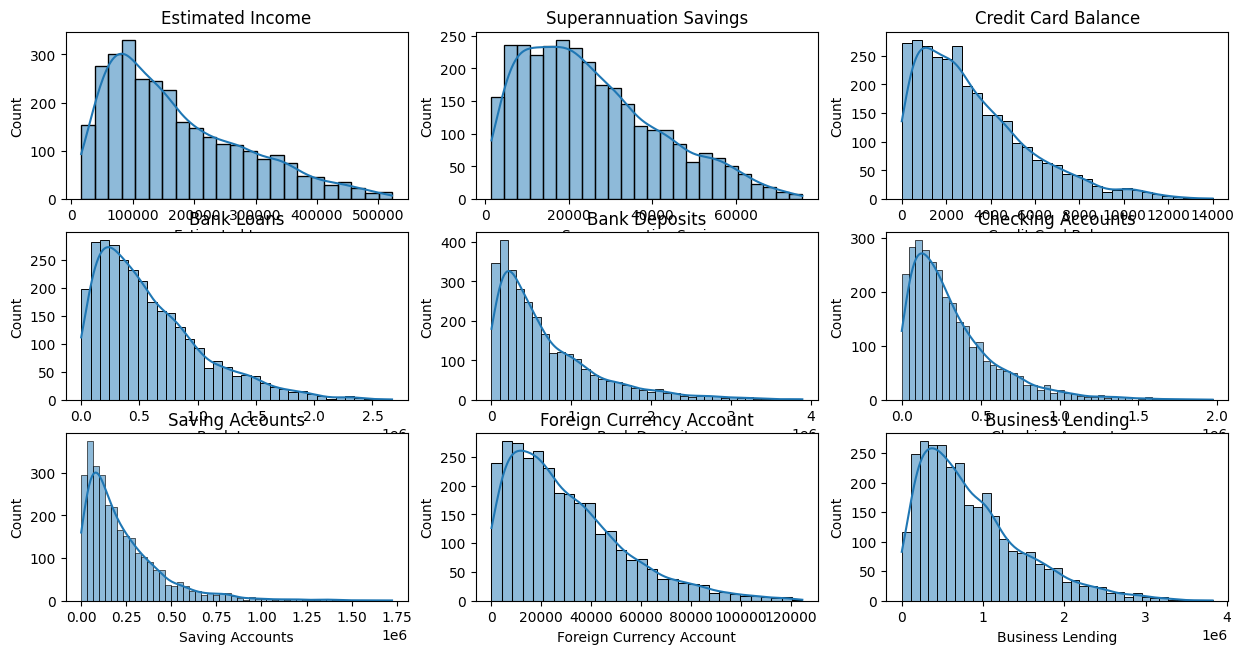

In [15]:
numerical_cols = ['Estimated Income', 'Superannuation Savings', 'Credit Card Balance', 'Bank Loans', 'Bank Deposits', 'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account', 'Business Lending']

# Univariate analysis and visualization
plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
  plt.subplot(4,3,i+1)
  sns.histplot(df[col],kde=True)
  plt.title(col)
plt.show()

# Heatmap

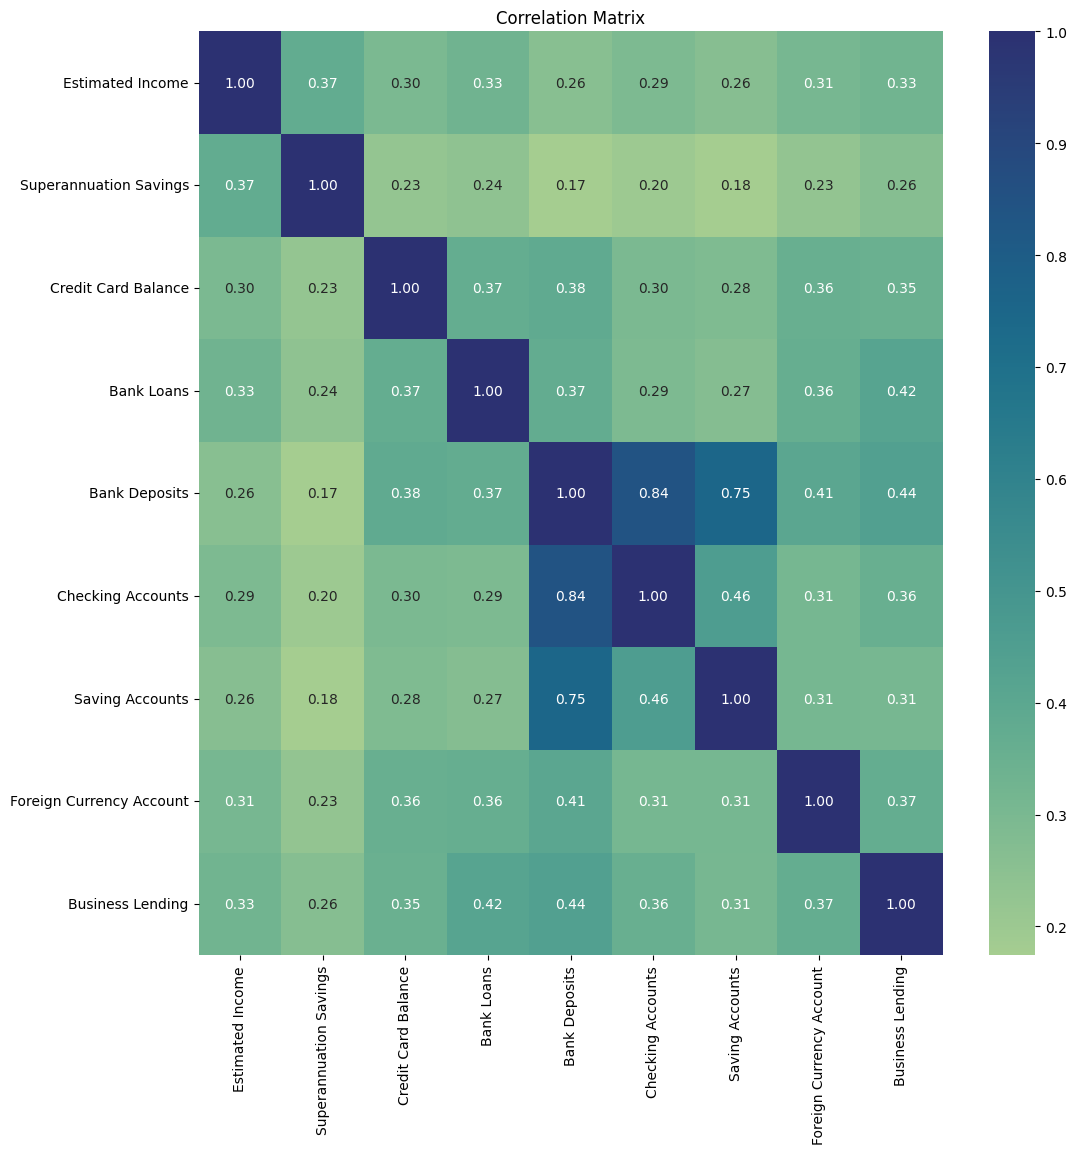

In [16]:
numerical_cols = ['Estimated Income', 'Superannuation Savings', 'Credit Card Balance', 'Bank Loans', 'Bank Deposits', 'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account', 'Business Lending']

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12,12))
sns.heatmap(correlation_matrix, annot=True, cmap='crest', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

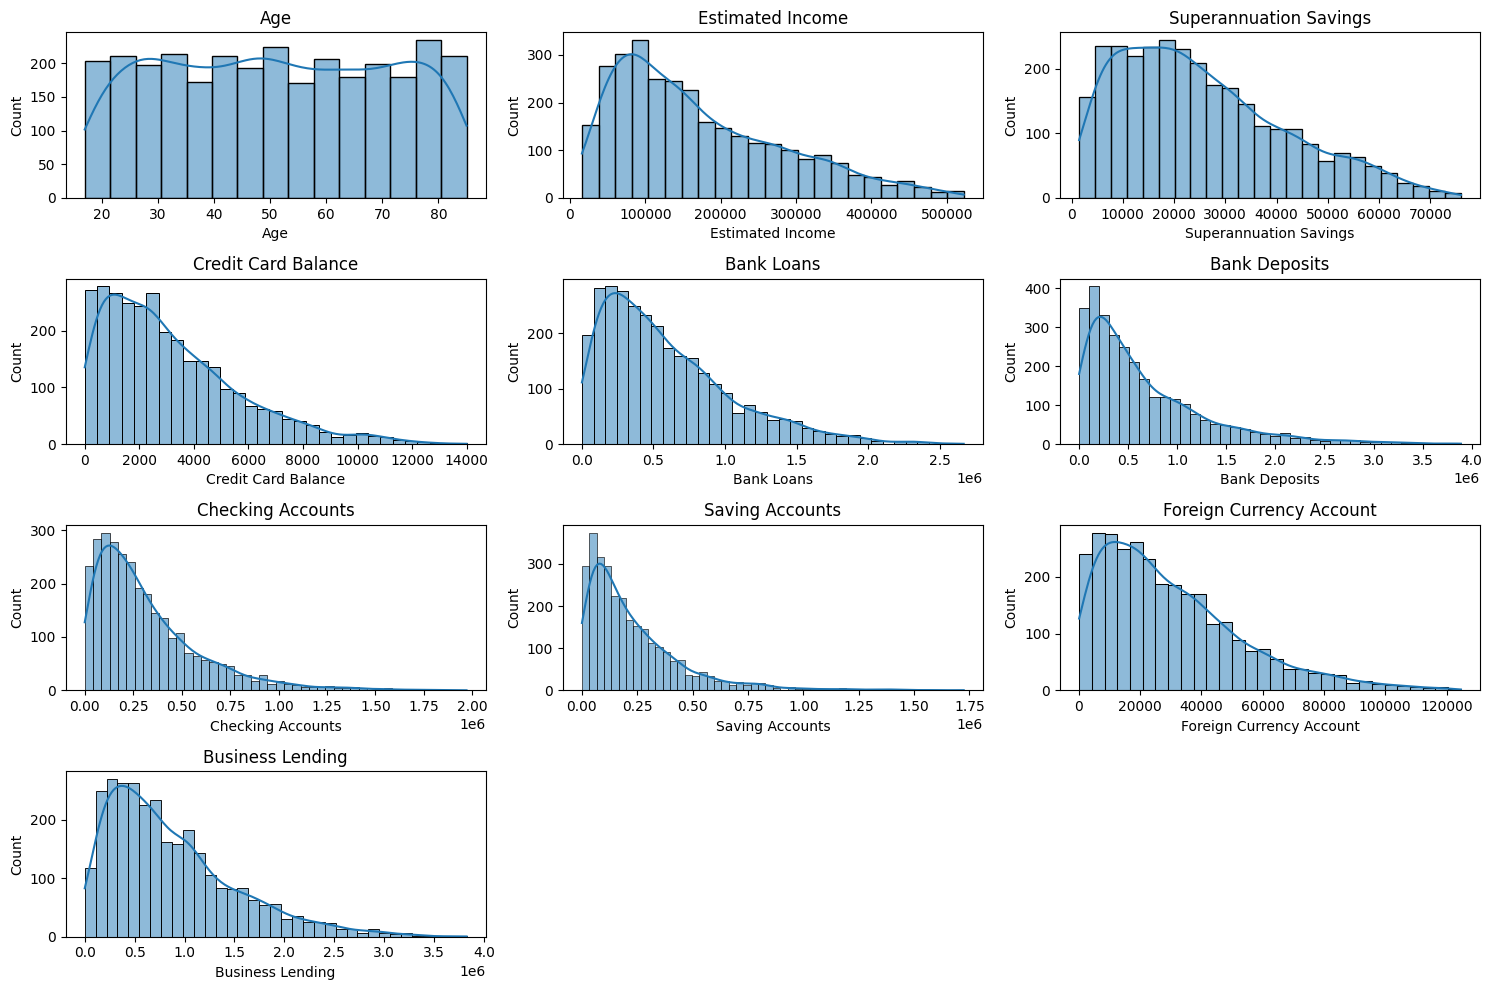

In [17]:
num_cols = ['Age', 'Estimated Income', 'Superannuation Savings', 
            'Credit Card Balance', 'Bank Loans', 'Bank Deposits', 
            'Checking Accounts', 'Saving Accounts', 
            'Foreign Currency Account', 'Business Lending']

cat_cols = ['Fee Structure']

# Numerical histograms
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()




# Data Transformation

In [18]:
# Create Risk_Category based on Risk Weighting
# 1-2: Low Risk, 3: Medium Risk, 4-5: High Risk
def categorize_risk(risk_weighting):
    if risk_weighting <= 2:
        return 'Low Risk'
    elif risk_weighting == 3:
        return 'Medium Risk'
    else:
        return 'High Risk'

df['Risk_Category'] = df['Risk Weighting'].apply(categorize_risk)
print("Risk_Category column created:")
print(df['Risk_Category'].value_counts())

Risk_Category column created:
Risk_Category
Low Risk       2058
High Risk       482
Medium Risk     460
Name: count, dtype: int64


In [19]:
# Save the cleaned dataset with risk categories
df.to_excel('Banking_Analysis.xlsx', index=False)
print("Analysis results saved to 'Banking_Analysis.xlsx'")

# Summary statistics for the report
summary_stats = {
    'Total_Customers': len(df),
    'High_Risk_Customers': len(df[df['Risk_Category'] == 'High Risk']),
    'Low_Risk_Customers': len(df[df['Risk_Category'] == 'Low Risk']),
    'Average_Risk_Weighting': df['Risk Weighting'].mean(),
    'Median_Risk_Weighting': df['Risk Weighting'].median()
}

print("\nProject Summary:")
for key, value in summary_stats.items():
    print(f"{key}: {value}")

print("\n✅ Banking Risk Analytics Project Completed!")
print("This analysis provides valuable insights for minimizing loan default risks.")

Analysis results saved to 'Banking_Analysis.xlsx'

Project Summary:
Total_Customers: 3000
High_Risk_Customers: 482
Low_Risk_Customers: 2058
Average_Risk_Weighting: 2.2493333333333334
Median_Risk_Weighting: 2.0

✅ Banking Risk Analytics Project Completed!
This analysis provides valuable insights for minimizing loan default risks.


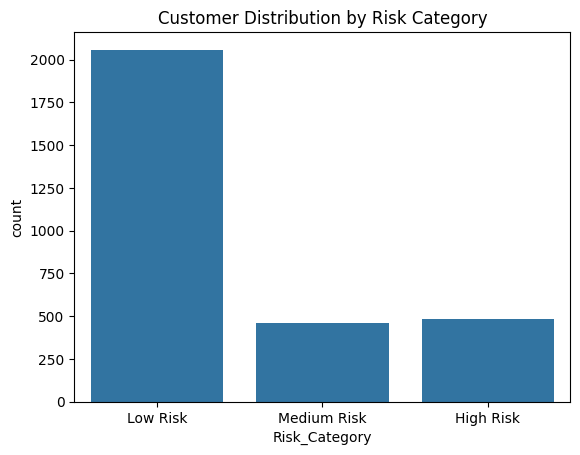

In [20]:
sns.countplot(data=df, x="Risk_Category")
plt.title("Customer Distribution by Risk Category")
plt.show()

In [21]:
df["Sex"] = df["GenderId"].map({1: "Male", 2: "Female"})
df.columns


Index(['Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank',
       'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure',
       'Loyalty Classification', 'Estimated Income', 'Superannuation Savings',
       'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending', 'Properties Owned',
       'Risk Weighting', 'BRId', 'GenderId', 'IAId', 'Income Band',
       'Risk_Category', 'Sex'],
      dtype='str')

In [22]:


# Define broad age bands
bins = [17, 30, 60, 85]   # ranges: 18–30, 31–60, 61–85
labels = ["Young", "Adult", "Senior"]

df["Age_Band"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True)

# Check distribution
print(df["Age_Band"].value_counts())


Age_Band
Adult     1306
Senior    1084
Young      571
Name: count, dtype: int64


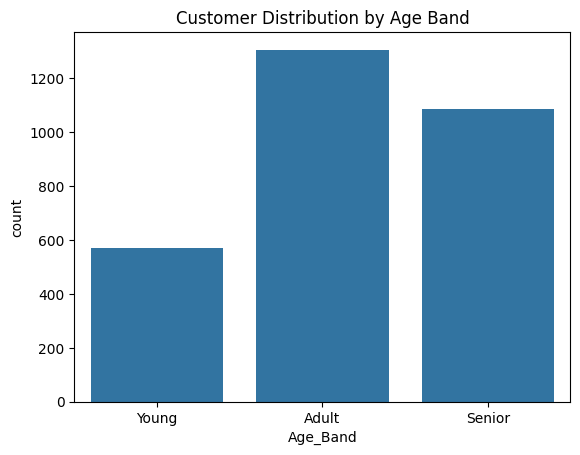

In [23]:
sns.countplot(data=df, x="Age_Band")
plt.title("Customer Distribution by Age Band")
plt.show()

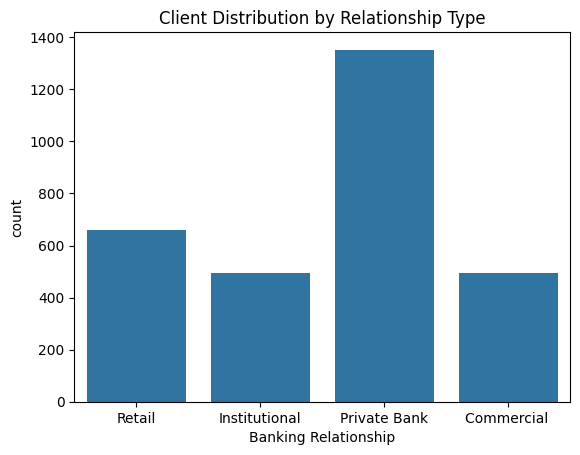

,Bank Deposits,Bank Loans
Banking Relationship,,
Commercial,679151.578901,609463.688400
Institutional,664581.704334,562823.162101
Private Bank,684466.371041,602230.187947
Retail,644685.417934,577091.193990


In [24]:
df["Banking Relationship"] = df["BRId"].map({1: "Retail", 2: "Institutional" ,3: "Private Bank" , 4: "Commercial "})
sns.countplot(data=df, x="Banking Relationship")
plt.title("Client Distribution by Relationship Type")
plt.show()

df.groupby("Banking Relationship")[["Bank Deposits","Bank Loans"]].mean()

Text(0, 0.5, 'Processing Fees')

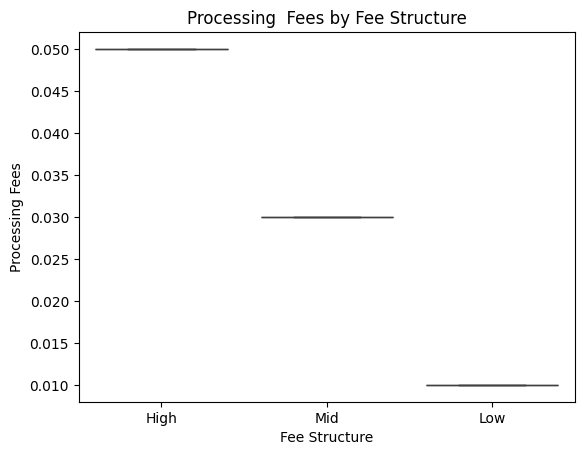

In [26]:
fee_map = {"high": 0.05, "mid": 0.03, "low": 0.01}
df["Processing Fees"] = df["Fee Structure"].str.lower().map(fee_map)

sns.boxplot(data=df, x="Fee Structure", y="Processing Fees")
plt.title("Processing  Fees by Fee Structure")
plt.xlabel("Fee Structure")
plt.ylabel("Processing Fees")

In [27]:
df.columns

Index(['Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank',
       'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure',
       'Loyalty Classification', 'Estimated Income', 'Superannuation Savings',
       'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending', 'Properties Owned',
       'Risk Weighting', 'BRId', 'GenderId', 'IAId', 'Income Band',
       'Risk_Category', 'Sex', 'Age_Band', 'Banking Relationship',
       'Processing Fees'],
      dtype='str')

In [28]:
df.shape

(3000, 31)

In [29]:
df.to_excel('Banking_Analysis.xlsx', index=False)

In [30]:
dh = pd.read_excel('Banking_Analysis.xlsx')
dh.columns

Index(['Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank',
       'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure',
       'Loyalty Classification', 'Estimated Income', 'Superannuation Savings',
       'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending', 'Properties Owned',
       'Risk Weighting', 'BRId', 'GenderId', 'IAId', 'Income Band',
       'Risk_Category', 'Sex', 'Age_Band', 'Banking Relationship',
       'Processing Fees'],
      dtype='str')